In [10]:
## Importing the tools. Tools used- Pandas,Numpy,Matplotlib,Seaborn,Scikit learn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [11]:
##Since I needed the complete data, I used pandas to read the data from the github source itself rather than downloading it.
df = pd.read_csv('https://raw.githubusercontent.com/IBM/employee-attrition-aif360/master/data/emp_attrition.csv')

In [5]:
## This shows the structure and datatypes of all the columns. This helps us understand how many columns there are, what they are and the datatypes they are.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [6]:
df.shape


(1470, 35)

In [7]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [8]:
## This command drops the columns that are redundant. The columns dropper here are consisted of non-uniquer values. So they don't  provide any analysis value to us in this project.
df.drop(columns=['EmployeeCount','EmployeeNumber','Over18','StandardHours'],inplace=True)


In [9]:
print (df)

      Age Attrition     BusinessTravel  DailyRate              Department  \
0      41       Yes      Travel_Rarely       1102                   Sales   
1      49        No  Travel_Frequently        279  Research & Development   
2      37       Yes      Travel_Rarely       1373  Research & Development   
3      33        No  Travel_Frequently       1392  Research & Development   
4      27        No      Travel_Rarely        591  Research & Development   
...   ...       ...                ...        ...                     ...   
1465   36        No  Travel_Frequently        884  Research & Development   
1466   39        No      Travel_Rarely        613  Research & Development   
1467   27        No      Travel_Rarely        155  Research & Development   
1468   49        No  Travel_Frequently       1023                   Sales   
1469   34        No      Travel_Rarely        628  Research & Development   

      DistanceFromHome  Education EducationField  EnvironmentSatisfaction  

In [12]:
##
def attrition_rate_by(col):
    rate= df.groupby (col)['Attrition'].apply(lambda x: (x== 'Yes').mean())
    return rate.sort_values(ascending=False)
print(attrition_rate_by('OverTime')) 
print(attrition_rate_by('Department')) 
print(attrition_rate_by('JobSatisfaction'))
print(attrition_rate_by('MaritalStatus'))
print(attrition_rate_by('JobRole'))
                        


OverTime
Yes    0.305288
No     0.104364
Name: Attrition, dtype: float64
Department
Sales                     0.206278
Human Resources           0.190476
Research & Development    0.138398
Name: Attrition, dtype: float64
JobSatisfaction
1    0.228374
3    0.165158
2    0.164286
4    0.113290
Name: Attrition, dtype: float64
MaritalStatus
Single      0.255319
Married     0.124814
Divorced    0.100917
Name: Attrition, dtype: float64
JobRole
Sales Representative         0.397590
Laboratory Technician        0.239382
Human Resources              0.230769
Sales Executive              0.174847
Research Scientist           0.160959
Manufacturing Director       0.068966
Healthcare Representative    0.068702
Manager                      0.049020
Research Director            0.025000
Name: Attrition, dtype: float64


In [ ]:
'attrition_rate_by' in dir()

In [6]:
def attrition_rate_by(col):
    rate = df.groupby(col)['Attrition'].apply(lambda x: (x == 'Yes').mean())
    return rate.sort_values(ascending=False)

In [13]:
pd.crosstab(df['Department'], df['OverTime'], normalize='index')

OverTime,No,Yes
Department,,
Human Resources,0.730159,0.269841
Research & Development,0.718002,0.281998
Sales,0.713004,0.286996


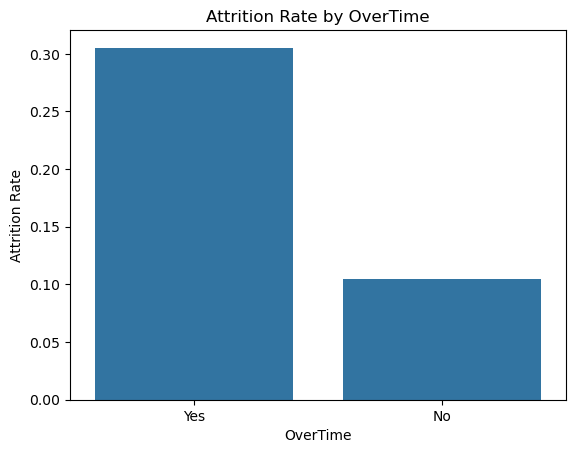

In [15]:
result = attrition_rate_by('OverTime')
sns.barplot(x=result.index, y=result.values)
plt.title('Attrition Rate by OverTime')
plt.ylabel('Attrition Rate')
plt.show()

In [19]:
df_numeric=df.copy()
df_numeric['Attrition']=df_numeric['Attrition'].map({'Yes':1,'No':0})


corr = df_numeric.select_dtypes(include=np.number).corr()['Attrition'].sort_values(ascending=False)
print(corr)

Attrition                   1.000000
DistanceFromHome            0.077924
NumCompaniesWorked          0.043494
MonthlyRate                 0.015170
PerformanceRating           0.002889
HourlyRate                 -0.006846
PercentSalaryHike          -0.013478
Education                  -0.031373
YearsSinceLastPromotion    -0.033019
RelationshipSatisfaction   -0.045872
DailyRate                  -0.056652
TrainingTimesLastYear      -0.059478
WorkLifeBalance            -0.063939
EnvironmentSatisfaction    -0.103369
JobSatisfaction            -0.103481
JobInvolvement             -0.130016
YearsAtCompany             -0.134392
StockOptionLevel           -0.137145
YearsWithCurrManager       -0.156199
Age                        -0.159205
MonthlyIncome              -0.159840
YearsInCurrentRole         -0.160545
JobLevel                   -0.169105
TotalWorkingYears          -0.171063
Name: Attrition, dtype: float64


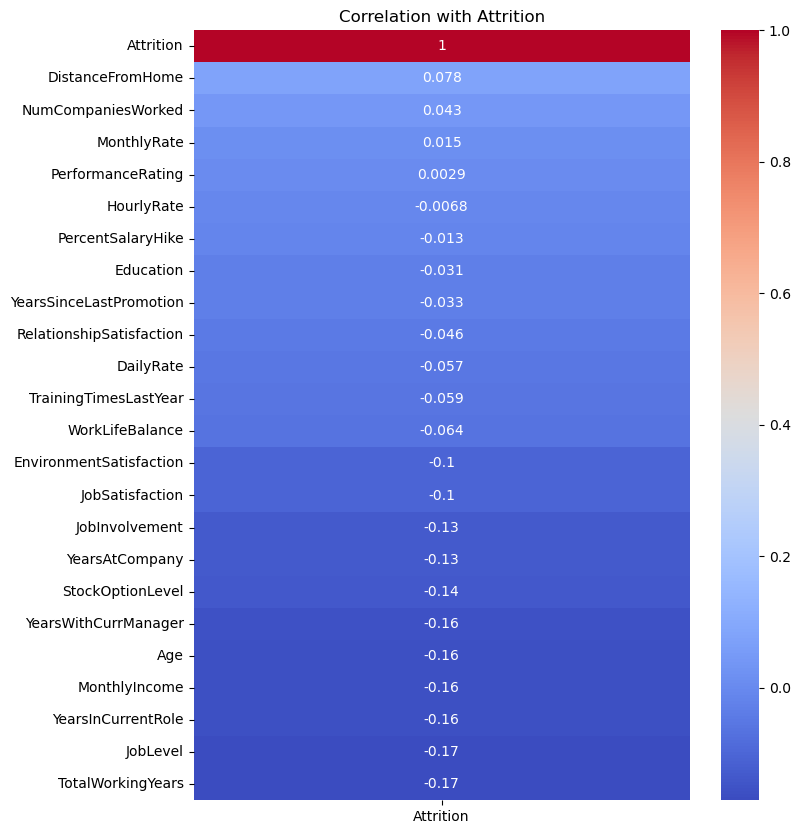

In [23]:
plt.figure(figsize=(8,10))
sns.heatmap(df_numeric.select_dtypes(include=np.number).corr()[['Attrition']].sort_values(by='Attrition',ascending=False),
            annot=True,cmap='coolwarm')
plt.title('Correlation with Attrition')
plt.show()

In [14]:
X = pd.get_dummies(df.drop(columns=['Attrition']), drop_first=True)
y = df['Attrition'].map({'Yes': 1, 'No': 0})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [15]:
X.shape
X_train.shape
X_test.shape
y_train.value_counts(normalize=True)
y_test.value_counts(normalize=True)

Attrition
0    0.840136
1    0.159864
Name: proportion, dtype: float64

In [18]:
log_model = LogisticRegression(class_weight='balanced', max_iter=10000)
log_model.fit(X_train, y_train)
y_pred = log_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.78      0.85       247
           1       0.38      0.70      0.49        47

    accuracy                           0.77       294
   macro avg       0.65      0.74      0.67       294
weighted avg       0.84      0.77      0.79       294



C:\Users\MAHADEVAN R\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [19]:
rf_model = RandomForestClassifier(class_weight='balanced', random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.85      0.99      0.91       247
           1       0.50      0.06      0.11        47

    accuracy                           0.84       294
   macro avg       0.67      0.53      0.51       294
weighted avg       0.79      0.84      0.78       294



In [20]:
# Pair each column name with its coefficient from the trained model
coefficients = pd.Series(log_model.coef_[0], index=X.columns).sort_values(ascending=False)

print("Top 10 features pushing TOWARD attrition (positive):")
print(coefficients.head(10))

print("\nTop 10 features pushing AWAY from attrition (negative):")
print(coefficients.tail(10))

Top 10 features pushing TOWARD attrition (positive):
OverTime_Yes                        1.690162
JobRole_Laboratory Technician       0.927557
BusinessTravel_Travel_Frequently    0.877779
MaritalStatus_Single                0.589895
JobRole_Sales Representative        0.520482
EducationField_Technical Degree     0.365685
Department_Sales                    0.339884
Gender_Male                         0.326568
BusinessTravel_Travel_Rarely        0.290943
PerformanceRating                   0.226612
dtype: float64

Top 10 features pushing AWAY from attrition (negative):
JobRole_Sales Executive             -0.215577
RelationshipSatisfaction            -0.268916
JobRole_Research Director           -0.298593
JobInvolvement                      -0.312606
StockOptionLevel                    -0.334329
JobSatisfaction                     -0.377076
Department_Research & Development   -0.387154
EnvironmentSatisfaction             -0.425688
EducationField_Other                -0.432733
JobRole_Res

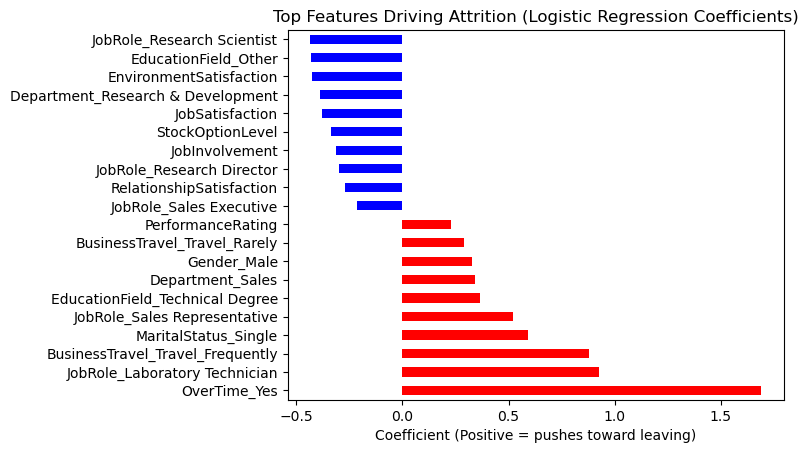

In [21]:
top_features = pd.concat([coefficients.head(10), coefficients.tail(10)])

top_features.plot(kind='barh', color=(top_features > 0).map({True: 'red', False: 'blue'}))
plt.title('Top Features Driving Attrition (Logistic Regression Coefficients)')
plt.xlabel('Coefficient (Positive = pushes toward leaving)')
plt.show()


In [23]:
plt.savefig('overtime_attrition.png', bbox_inches='tight', dpi=150)

<Figure size 640x480 with 0 Axes>

In [24]:
plt.savefig('Top Features Driving Attrition (Logistic Regression Coefficients)', bbox_inches='tight', dpi=150)

<Figure size 640x480 with 0 Axes>

In [25]:
plt.savefig('Correlation with Attrition', bbox_inches='tight', dpi=150)

<Figure size 640x480 with 0 Axes>